# Module 5 Lab 2: Textbook Problem 5.3

**CS 82A - Introduction to Data Science**

**Ramisha Tasfia**

**GitHub:** [https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module5/lab2/module5_lab2.ipynb](https://github.com/ramishatasfia5156-commits/cs82a-coursework/blob/main/module5/lab2/module5_lab2.ipynb)

## Load the Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

cust = pd.read_csv("custdata.tsv", sep="\t")
print("Shape as loaded:", cust.shape)
print()
print(cust["housing.type"].value_counts(dropna=False))

Shape as loaded: (1000, 11)

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
NaN                              56
Occupied with no rent            11
Name: count, dtype: int64


## Count and Remove the NA Housing Entries

In [2]:
na_count = cust["housing.type"].isna().sum()
print("Rows with NA housing type:", na_count)

# subset: keep only rows that have a housing type
housing = cust[cust["housing.type"].notna()]
print("Rows before:", len(cust))
print("Rows after:", len(housing))
print("Excluded:", len(cust) - len(housing))

Rows with NA housing type: 56
Rows before: 1000
Rows after: 944
Excluded: 56


## Rows Excluded
Before creating this chart, I eliminated all customer rows with "missing" (or "NA") as their housing type. Out of the 1,000 customers that were in my data, there are 56 that had no housing type recorded; therefore, I removed these 56 rows from the data. Removing these 56 rows resulted in me having 944 customer rows on the chart.

## Customers per Housing Type

In [3]:
housing_counts = (housing["housing.type"]
                  .value_counts()
                  .sort_values(ascending=False))
print(housing_counts)
print()
print("Total charted:", housing_counts.sum())

housing.type
Homeowner with mortgage/loan    412
Rented                          364
Homeowner free and clear        157
Occupied with no rent            11
Name: count, dtype: int64

Total charted: 944


## Housing Type Bar Chart

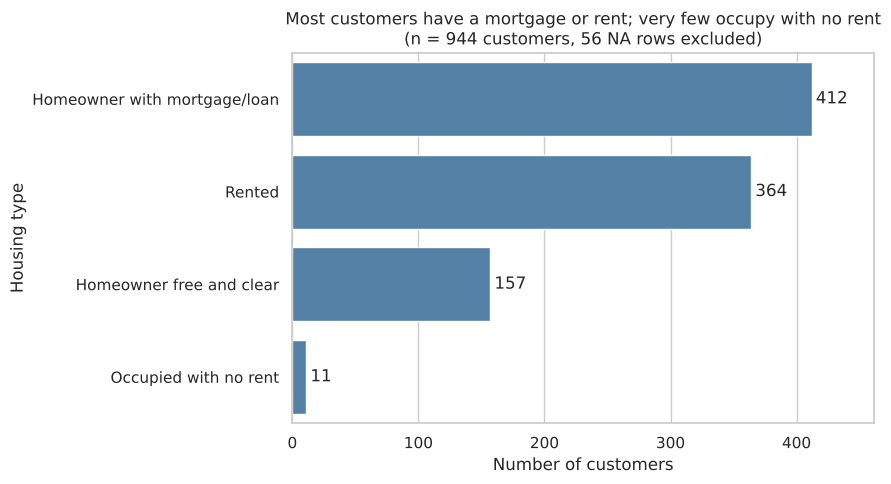

In [4]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=housing_counts.values,
                 y=housing_counts.index,
                 order=housing_counts.index,
                 color="steelblue")
ax.bar_label(ax.containers[0], padding=3)
plt.title("Most customers have a mortgage or rent; "
          "very few occupy with no rent\n"
          "(n = 944 customers, 56 NA rows excluded)")
plt.xlabel("Number of customers")
plt.ylabel("Housing type")
# zero baseline, plus room for the count labels
plt.xlim(0, housing_counts.max() * 1.12)
plt.tight_layout()
plt.show()

## AI Disclosure
Claude (Anthropic) was used to help explain concepts and draft the code for this lab. All code was reviewed and understood by me, and I rewrote the written responses in my own words. I can explain why the NA housing entries have to be removed before charting, how the subset keeps only rows that have a housing type, why the bars are sorted from largest to smallest, and why 56 of the 1,000 rows were excluded.

Key prompt: "Help me with Module 5 Lab 2: Textbook Problem 5.3 using the attached data."